In [7]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
import re


In [8]:
# Load the data
data = pd.read_excel('data-spell-checker.xlsx')
data.head()

,word,label
0,අභිචෝදකයා,1
1,අංකනය,1
2,අංකන,1
3,අංකය,1
4,අංකාන්තරය,1


In [9]:
# Data preprocessing
X = data['word'].apply(lambda x: x.lower())  # Lowercasing
X = X.apply(lambda x: re.sub(r'[^\w\s]', '', x))  # Remove special characters
y = data['label']

In [10]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Feature extraction using Bag-of-Words
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

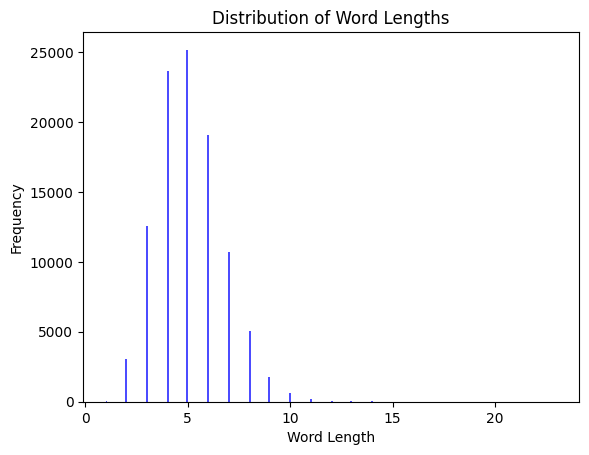

In [12]:
# Visualization: Word count distribution
word_lengths = X.apply(len)
plt.hist(word_lengths, bins='auto', alpha=0.7, color='blue')
plt.title('Distribution of Word Lengths')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.show()

In [13]:
# Naive Bayes
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_vectorized, y_train)
nb_predictions = nb_classifier.predict(X_test_vectorized)
nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", nb_accuracy)
print(classification_report(y_test, nb_predictions))

Naive Bayes Accuracy: 0.6992506978794261
              precision    recall  f1-score   support

           0       0.78      0.18      0.30      7086
           1       0.69      0.97      0.81     13333

    accuracy                           0.70     20419
   macro avg       0.74      0.58      0.55     20419
weighted avg       0.72      0.70      0.63     20419



In [15]:
# Support Vector Machine
svm_parameters = {'C': [0.1, 1, 10, 100],
                  'kernel': ['linear', 'rbf'],
                  'gamma': ['scale', 'auto']}
svm_classifier = RandomizedSearchCV(SVC(), svm_parameters, n_iter=10, cv=3, random_state=42)
svm_classifier.fit(X_train_vectorized, y_train)
svm_predictions = svm_classifier.predict(X_test_vectorized)
svm_accuracy = accuracy_score(y_test, svm_predictions)

print("SVM Accuracy:", svm_accuracy)
print(classification_report(y_test, svm_predictions))


SVM Accuracy: 0.6993976198638523
              precision    recall  f1-score   support

           0       0.78      0.19      0.30      7086
           1       0.69      0.97      0.81     13333

    accuracy                           0.70     20419
   macro avg       0.74      0.58      0.55     20419
weighted avg       0.72      0.70      0.63     20419



In [16]:
from sklearn.ensemble import GradientBoostingClassifier  # Import GradientBoostingClassifier

# Train and evaluate Gradient Boosting Machine (GBM)
gbm_classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gbm_classifier.fit(X_train_vectorized, y_train)
gbm_predictions = gbm_classifier.predict(X_test_vectorized)
gbm_accuracy = accuracy_score(y_test, gbm_predictions)
print("Gradient Boosting Machine (GBM) Accuracy:", gbm_accuracy)
print(classification_report(y_test, gbm_predictions))

Gradient Boosting Machine (GBM) Accuracy: 0.6537048827072824
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      7086
           1       0.65      1.00      0.79     13333

    accuracy                           0.65     20419
   macro avg       0.83      0.50      0.40     20419
weighted avg       0.77      0.65      0.52     20419



In [17]:
# Train and evaluate K-Nearest Neighbors (KNN)
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train_vectorized, y_train)
knn_predictions = knn_classifier.predict(X_test_vectorized)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print("K-Nearest Neighbors (KNN) Accuracy:", knn_accuracy)
print(classification_report(y_test, knn_predictions))

K-Nearest Neighbors (KNN) Accuracy: 0.6682501591654831
              precision    recall  f1-score   support

           0       0.81      0.06      0.11      7086
           1       0.66      0.99      0.80     13333

    accuracy                           0.67     20419
   macro avg       0.74      0.53      0.45     20419
weighted avg       0.72      0.67      0.56     20419



In [18]:
# Train and evaluate Decision Trees
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_vectorized, y_train)
dt_predictions = dt_classifier.predict(X_test_vectorized)
dt_accuracy = accuracy_score(y_test, dt_predictions)
print("Decision Trees Accuracy:", dt_accuracy)
print(classification_report(y_test, dt_predictions))

Decision Trees Accuracy: 0.6980753220040159
              precision    recall  f1-score   support

           0       0.75      0.20      0.31      7086
           1       0.69      0.96      0.81     13333

    accuracy                           0.70     20419
   macro avg       0.72      0.58      0.56     20419
weighted avg       0.71      0.70      0.63     20419



In [19]:
# Random Forest
rf_parameters = {'n_estimators': [100, 200, 300],
                 'max_depth': [None, 10, 20, 30],
                 'min_samples_split': [2, 5, 10],
                 'min_samples_leaf': [1, 2, 4]}
rf_classifier = RandomizedSearchCV(RandomForestClassifier(), rf_parameters, n_iter=10, cv=3, random_state=42)
rf_classifier.fit(X_train_vectorized, y_train)
rf_predictions = rf_classifier.predict(X_test_vectorized)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)
print(classification_report(y_test, rf_predictions))


Random Forest Accuracy: 0.6993486458690436
              precision    recall  f1-score   support

           0       0.78      0.19      0.30      7086
           1       0.69      0.97      0.81     13333

    accuracy                           0.70     20419
   macro avg       0.73      0.58      0.56     20419
weighted avg       0.72      0.70      0.63     20419

